In [1]:
import matplotlib.pylab as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

## Initial Design in 2D

We start with the 2D design and aim to optimize its coupling efficiency as much as possible. This way, the design process is faster and costs fewer FlexCredits.

First define the wavelength range of interest.

In [2]:
lda0 = 1.31  # central wavelength
freq0 = td.C_0 / lda0  # central frequency
ldas = np.linspace(1.2, 1.4, 201)  # wavelength range
freqs = td.C_0 / ldas  # frequency range
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))  # width of the source frequency range

Grating couplers are relatively narrow band device. Within the working bandwidth, the refractive indices of silicon and oxide don't change noticeably. Therefore, for simplicity we will just model them as nondispersive mediums. 

In [3]:
n_si = 3.48
si = td.Medium(permittivity=n_si**2)
si_toc = 1.8e-4 # Thermo-optic coefficient of silicon (K^-1)

n_si3n4 = 1.96274
si3n4 = td.Medium(permittivity=n_si3n4**2)
si3n4_toc = 2.5e-5 # Thermo-optic coefficient of silicon nitride (K^-1)

n_sio2 = 1.44384
sio2 = td.Medium(permittivity=n_sio2**2)
sio2_toc = 8.4E-6 # Thermo-optic coeffici   ent of silicon dioxide (K^-1)

n_tio2 = 2.4
tio2 = td.Medium(permittivity=n_tio2**2)
tio2_toc = -2e-4 # Thermo-optic coefficient of titanium dioxide (K^-1)


Define geometry parameters. In this case, we have a silicon layer of 260 nm thickness. The grating will be partially etched with an etching depth of 160 nm. The filling fraction is set to be 80% in this case. A higher filling fraction will lead to a smaller gap size so this needs to be chosen according to the fabrication. The BOX layer has a thickness of 2 μm and the top oxide cladding has a thickness of 680 nm. 

In [4]:
t_si3n4 = 0.4  # thickness of the silicon nitride layer
t_tox = 5.0  # top oxide layer thickness
t_box = 5.0  # bottom oxide layer thickness

The goal is to couple between a single-mode waveguide and a single-mode fiber with a mode field diameter of 10.8 μm at an angle of 14.5 degrees.

In [5]:
theta = np.deg2rad(0)  # fiber tilt angle
mfd = 9.0  # mode field diameter

inf_eff = 1.0e3  # effective infinity
buffer = 0.6 * lda0  # buffer spacing to pad the simulation domain

Next we define some [Structures](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Structure.html) that are not changing in the design. This includes the top oxide layer, BOX layer, slab waveguide layer, etc. 

In [6]:
# create the top oxide layer
tox = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(inf_eff, inf_eff, t_tox)),
    medium=tio2,
)

# create the slab waveguide
slab_waveguide = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(0, inf_eff, t_si3n4)),
    medium=si3n4,
)

# create the bottom oxide layer
box = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -t_box), rmax=(inf_eff, inf_eff, 0)),
    medium=sio2,
)

# create the silicon substrate layer
substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, -t_box)
    ),
    medium=si,
)

In [ ]:
w_wg = 0.8  # waveguide width
l_taper = 5.0  # length of the linear taper


def make_3d_sim(p: float, source_x: float) -> td.Simulation:
    """Function to create a 2D simulation given the grating period and source position"""

    source_gap = 0.5

    # define a gaussian beam source
    source = td.GaussianBeam(
        size=(2 * mfd, 2 * mfd, 0),
        center=[source_x, 0, t_tox + source_gap],
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        angle_theta=theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # 90 degree polarization angle for TE polarization
    )

    # define a mode monitor
    mode_monitor = td.ModeMonitor(
        center=(-
                 -buffer - l_taper + 0.5, 0, t_si3n4 / 2),
        size=(0, 4 * w_wg, 6 * t_si3n4),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=n_si3n4),
        name="mode",
    )

    # create the grating structure
    gratings = td.Structure(geometry=gratings, medium=si3n4)

    vertices = [
        (0, w_grating / 2),
        (0, -w_grating / 2),
        (-l_taper, -w_wg / 2),
        (-l_taper - 2 * buffer, -w_wg / 2),
        (-l_taper - 2 * buffer, w_wg / 2),
        (-l_taper, w_wg / 2),
    ]
    
    taper = td.Structure(
        geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(0, t_si3n4)), medium=si3n4
    )

    # create a box to represent the simulation domain box
    sim_box = td.Box.from_bounds(
        rmin=(-buffer - l_taper, -w_grating / 2 - buffer, -t_box - buffer),
        rmax=(l_grating + buffer, w_grating / 2 + buffer, t_si3n4 + t_tox + buffer),
    )

    run_time = 2e-12  # simulation run time
    # Refine the grid over the GC region.
    refine_box = td.MeshOverrideStructure(
        geometry=td.Box(center=(size_x / 2, 0, 0), 
                        size=(td.inf, td.inf, 2 * t_si3n4)),
        dl=[0.02, 0.02, 0.02],
    )
    # construct simulation
    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec = td.GridSpec(grid_x = td.AutoGrid(min_steps_per_wvl = 20, ),
                                grid_y = td.AutoGrid(min_steps_per_wvl = 20, ), 
                                grid_z = td.AutoGrid(min_steps_per_wvl = 20, ), 
                                wavelength = lda0,
                                override_structures=[refine_box],
                                ), 
        subpixel = td.SubpixelSpec(dielectric = td.PolarizedAveraging(), 
                                metal = td.Staircasing(), 
                                pec = td.PECConformal(timestep_reduction = 0.3), ),         
        structures=[
            tox,
            gratings,
            # etched_waveguide,
            taper,
            box,
            substrate,
        ],
        sources=[source],
        monitors=[mode_monitor],
        run_time=run_time,
        symmetry=(0, -1, 0),
    )
    return sim

Generate the simulation using the optimal parameters from the 2D design. 

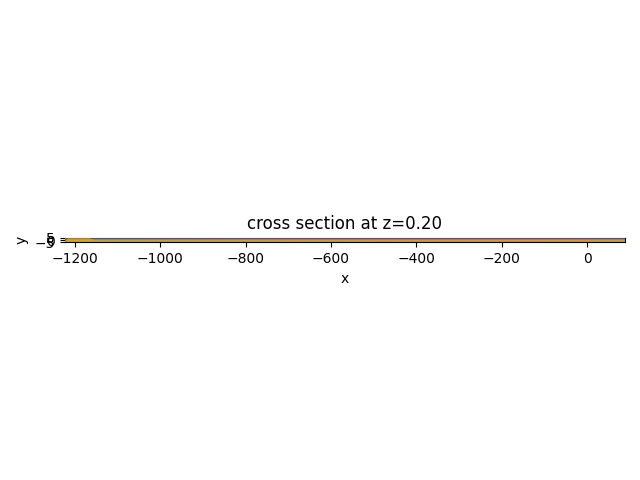

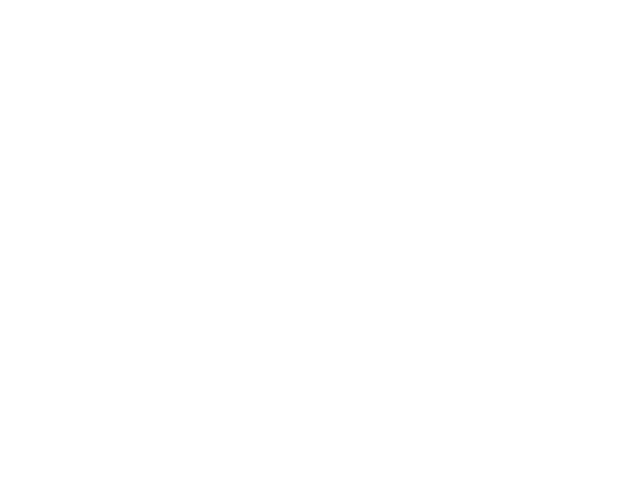

In [123]:
sim_3d = make_3d_sim(p=best_p, source_x=best_source_x)
plt.figure()
sim_3d.plot(z = t_si3n4/2)
plt.show()

Run the 3D simulation.

In [124]:
sim_data = web.run(simulation=sim_3d, task_name="3D_GC")

22:09:37 Eastern Daylight Time Created task '3D_GC' with task_id                
                               'fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=91459;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=811315;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\taskId]8;;\
                               ]8;id=91459;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\=]8;;\]8;id=383884;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\fdve]8;;\]8;id=91459;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\-0bc4b52f-56b3-461a-971f-d1354d11e2a0']8;;\.

Output()

22:09:44 Eastern Daylight Time status = queued

                               To cancel the simulation, use                    
                               'web.abort(task_id)' or 'web.delete(task_id)' or 
                               abort/delete the task in the web UI. Terminating 
                               the Python script will not stop the job running  
                               on the cloud.

...

Output()

23:24:45 Eastern Daylight Time status = success

23:24:46 Eastern Daylight Time View simulation result at                        
                               ]8;id=445433;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=655762;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\taskId]8;;\
                               ]8;id=445433;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\=]8;;\]8;id=686681;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\fdve]8;;\]8;id=445433;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bc4b52f-56b3-461a-971f-d1354d11e2a0\-0bc4b52f-56b3-461a-971f-d1354d11e2a0']8;;\.

Output()

23:24:48 Eastern Daylight Time loading simulation from simulation_data.hdf5

Plot the coupling efficiency as a function of wavelength. Compared to 2D, the coupling efficiency of -4 dB is slightly lower in 3D. This is because of two factors: 1. the taper introduces some loss during the mode size conversion down to the single-mode waveguide; 2. The optimal parameters in 2D can differ slightly from the optimal parameters in 3D. 

One can perform a parameter sweep similar to the 2D case to further optimize the design. For simplicity, we skip this part in this notebook.

3 dB Bandwidth: 68.00 nm


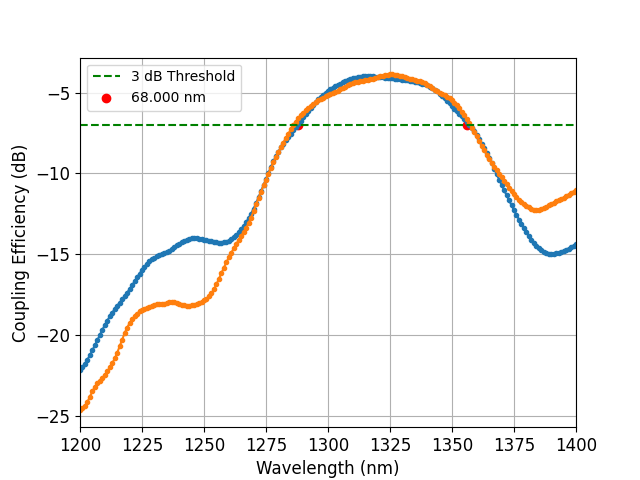

In [137]:
ce_3d = np.abs(sim_data["mode"].amps.sel(direction="-")) ** 2
plt.figure()
plt.plot(ldas*1e3, 10 * np.log10(ce_3d), '.-')
plt.plot(ldas*1e3, 10 * np.log10(ce), '.-')

# # plt.ylim(-12, 0)
# plt.xlabel("Wavelength (μm)")
# plt.ylabel("Coupling efficiency (dB)")
# plt.grid()
# plt.show()


# Find the maximum coupling efficiency
max_ce_3d = np.max(ce_3d)
max_ce_3d_db = 10 * np.log10(max_ce_3d)

# Calculate the 3 dB bandwidth
threshold_3d = max_ce_3d_db - 3
ldas_db_3d = 10 * np.log10(ce_3d)
indices_3d = np.where(ldas_db_3d >= threshold_3d)[0]
ldas_3db_3d = ldas[indices_3d]
# Calculate and print the 3 dB bandwidth
bandwidth_3db_3d = (ldas_3db_3d[-1] - ldas_3db_3d[0]) * 1e3  # Convert to nm

# Mark the 3 dB points on the plot
plt.axhline(y=threshold_3d, color='green', linestyle='--', label="3 dB Threshold")
plt.scatter([ldas_3db_3d[0]*1e3, ldas_3db_3d[-1]*1e3], [threshold_3d, threshold_3d], color='red', label="{:.3f} nm".format(bandwidth_3db_3d))
plt.legend()
plt.xlabel("Wavelength (nm)", fontsize=12)
plt.ylabel("Coupling Efficiency (dB)", fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid()
plt.xlim(1200, 1400)
# plt.ylim(-15, 0)  # Set the y-axis limits



print(f"3 dB Bandwidth: {bandwidth_3db_3d:.2f} nm")

## Final Remarks

In this notebook, we use the Gaussian beam as the source and use a mode monitor to measure the coupling efficiency. Due to reciprocity, one can use a mode source at the waveguide as excitation and then take the radiated field and do a mode overlap with a Gaussian profile to calculate the same value. In addition, in this setup, one can also perform near field to far field projection by using monitors like [FieldProjectionAngleMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldProjectionAngleMonitor.html) to investigate he radiation angle of the grating if that's of interest.

In the simulations we only focus on the coupling efficiency and hence only use a [ModeMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeMonitor.html) to measure the power of the fundamental mode in the waveguide. One can also add [FieldMonitors](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html) in the simulations to help visualize the field distribution if needed. 